In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the advertising dataset
df = pd.read_csv('Advertising.csv')

# Drop the unnamed index column if it exists to clean the data
if df.columns[0] == 'Unnamed: 0' or df.columns[0] == '':
    df = df.drop(df.columns[0], axis=1)

# Display the first 5 rows of the dataset
print("First 5 rows of the Advertising & Sales dataset:")
print(df.head())

First 5 rows of the Advertising & Sales dataset:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


In [2]:
# Check dataset dimensions (rows, columns)
print(f"Dataset Structure: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Check for missing values in the features and target variable
print("Checking for missing values in each column:")
print(df.isnull().sum())

# Display basic statistical details of the data
print("\nStatistical summary of the dataset:")
print(df.describe())

Dataset Structure: 200 rows and 4 columns.

Checking for missing values in each column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Statistical summary of the dataset:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


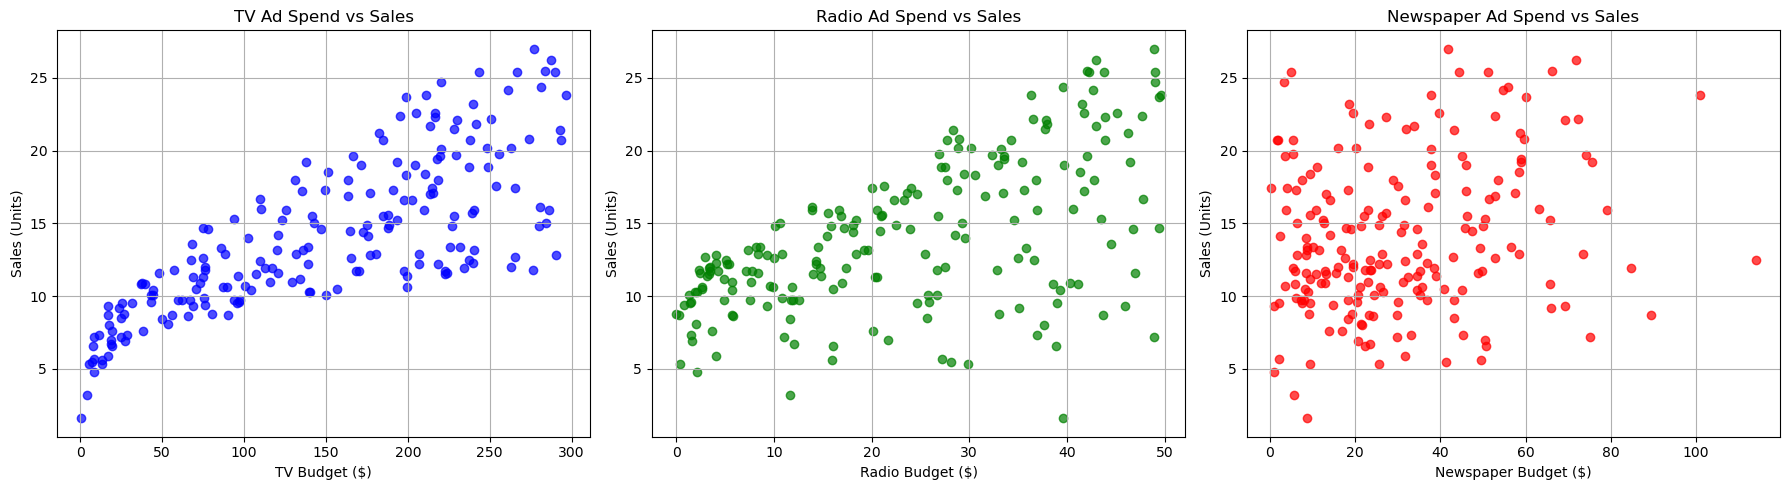

In [4]:
# Set up the plotting area for 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot TV vs Sales
axes[0].scatter(df['TV'], df['Sales'], color='blue', alpha=0.7)
axes[0].set_title('TV Ad Spend vs Sales')
axes[0].set_xlabel('TV Budget ($)')
axes[0].set_ylabel('Sales (Units)')
axes[0].grid(True)

# Plot Radio vs Sales
axes[1].scatter(df['Radio'], df['Sales'], color='green', alpha=0.7)
axes[1].set_title('Radio Ad Spend vs Sales')
axes[1].set_xlabel('Radio Budget ($)')
axes[1].set_ylabel('Sales (Units)')
axes[1].grid(True)

# Plot Newspaper vs Sales
axes[2].scatter(df['Newspaper'], df['Sales'], color='red', alpha=0.7)
axes[2].set_title('Newspaper Ad Spend vs Sales')
axes[2].set_xlabel('Newspaper Budget ($)')
axes[2].set_ylabel('Sales (Units)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

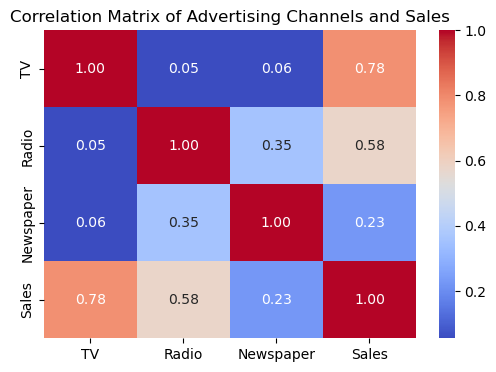

In [5]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Plot correlation heatmap to identify the strongest business drivers
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Advertising Channels and Sales')
plt.show()

# Separate features (X) and target variable (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [7]:
from sklearn.model_selection import train_test_split

# Split dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of testing samples: {X_test.shape[0]}")

Number of training samples: 160
Number of testing samples: 40


In [8]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression forecasting model
sales_model = LinearRegression()

# Train the model on training data
sales_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = sales_model.predict(X_test)

print("Linear Regression Sales forecasting model trained successfully!")

Linear Regression Sales forecasting model trained successfully!


In [9]:
from sklearn.metrics import r2_score, mean_absolute_error

# Evaluate model performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("==================================================")
print("             MODEL EVALUATION METRICS             ")
print("==================================================")
print(f"🎯 Model R-squared (Accuracy) Score: {r2 * 100:.2f}%")
print(f"📝 Mean Absolute Error: {mae:.2f} units")
print("==================================================\n")

print("==================================================")
print("      ACTIONABLE BUSINESS MARKETING STRATEGIES    ")
print("==================================================")
# Print coefficients for each channel to deliver insights
coefficients = sales_model.coef_
print(f"📈 TV Impact Coefficient: {coefficients[0]:.4f}")
print(f"📈 Radio Impact Coefficient: {coefficients[1]:.4f}")
print(f"📈 Newspaper Impact Coefficient: {coefficients[2]:.4f}")
print("--------------------------------------------------")
print("Strategic Recommendation for Marketing Budget:")
print("1. Allocate the maximum budget to TV and Radio as they show strong positive impact on sales.")
print("2. Reduce or optimize the spending on Newspaper advertising as its impact is minimal.")
print("==================================================")

             MODEL EVALUATION METRICS             
🎯 Model R-squared (Accuracy) Score: 89.94%
📝 Mean Absolute Error: 1.46 units

      ACTIONABLE BUSINESS MARKETING STRATEGIES    
📈 TV Impact Coefficient: 0.0447
📈 Radio Impact Coefficient: 0.1892
📈 Newspaper Impact Coefficient: 0.0028
--------------------------------------------------
Strategic Recommendation for Marketing Budget:
1. Allocate the maximum budget to TV and Radio as they show strong positive impact on sales.
2. Reduce or optimize the spending on Newspaper advertising as its impact is minimal.
